In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/census_income.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.shape

(32561, 15)

## As only 24 duplicates out of 32561 records so ignored those.

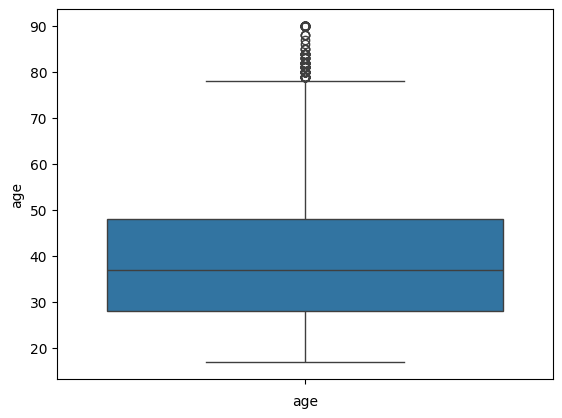

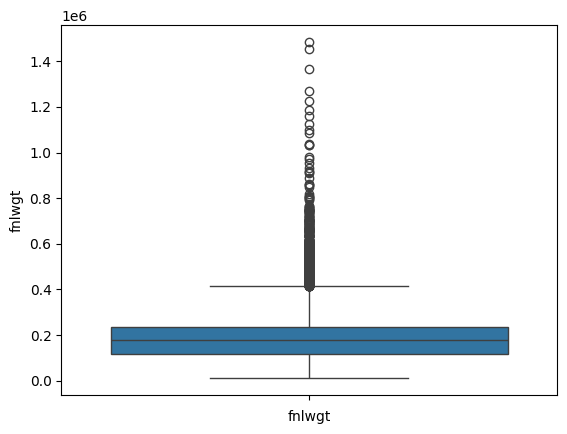

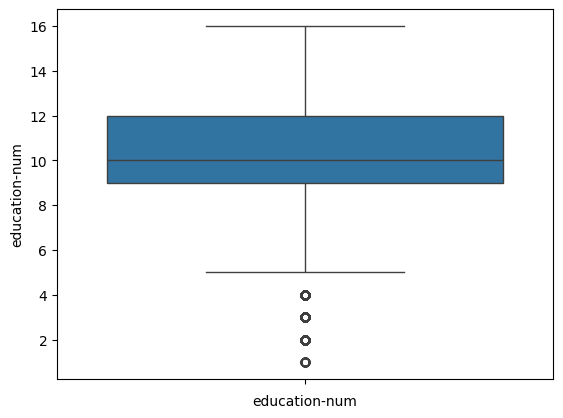

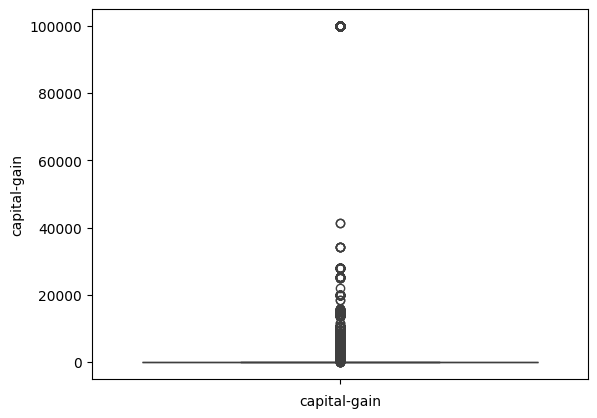

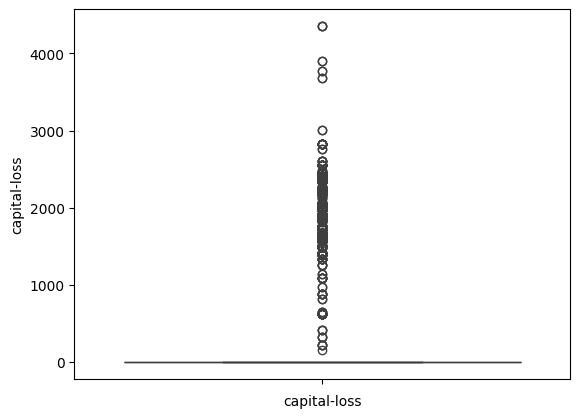

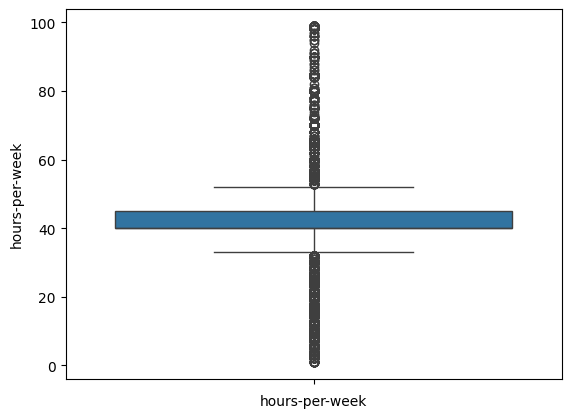

In [ ]:
#Outliers checking
for i in df.columns:
  if df[i].dtype=='int64' or df[i].dtype=='float64':
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
df['annual_income'].value_counts()

,count
annual_income,
<=50K,24720
>50K,7841


In [ ]:
df['annual_income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder


In [ ]:
#Coverted object type columns into numeric
LE = LabelEncoder()
for col in df.columns:
  if(df[col].dtype=='object'):
    df[col]=LE.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int64
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  int64
 6   occupation      32561 non-null  int64
 7   relationship    32561 non-null  int64
 8   race            32561 non-null  int64
 9   sex             32561 non-null  int64
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  int64
 14  annual_income   32561 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


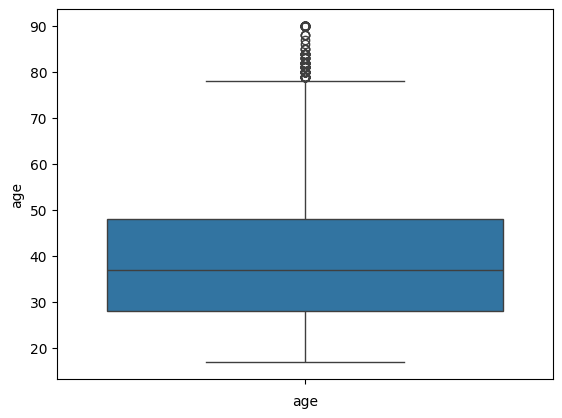

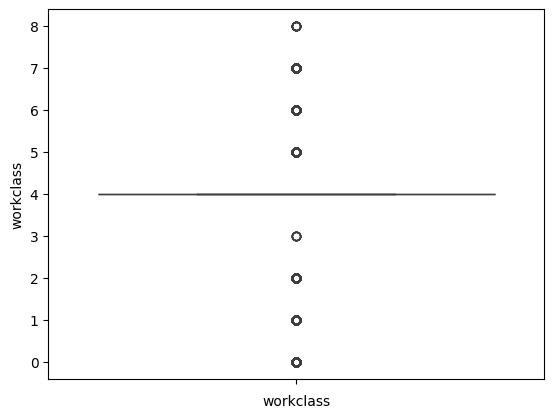

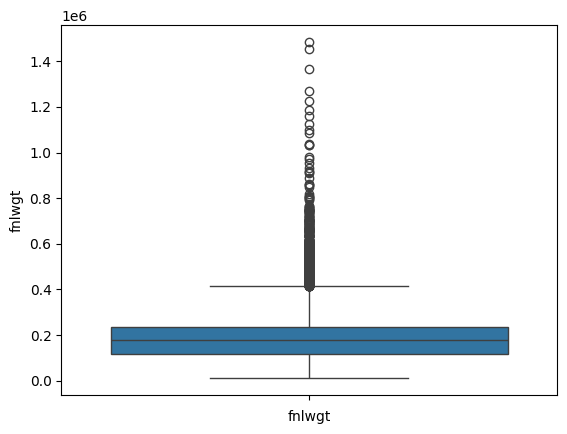

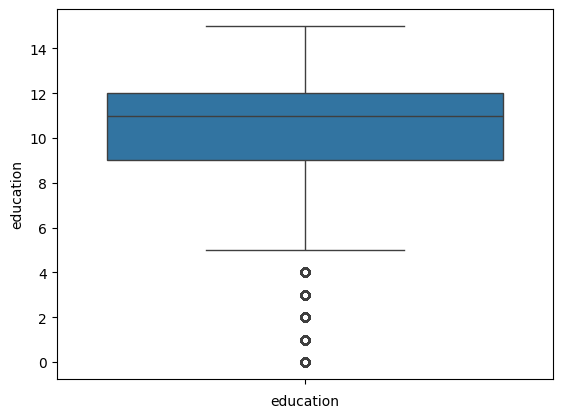

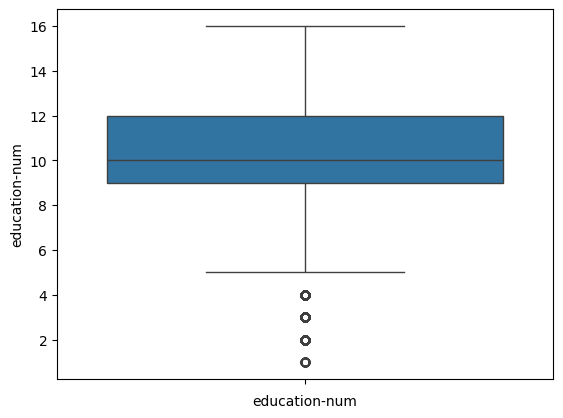

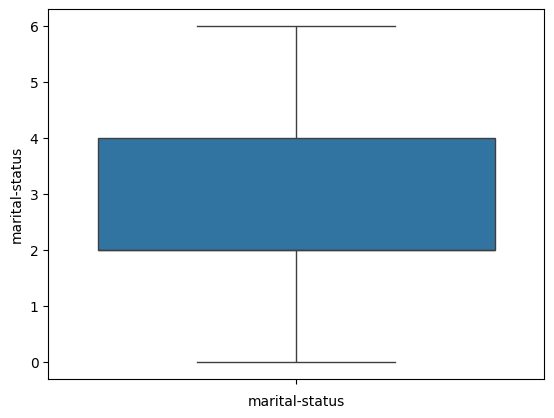

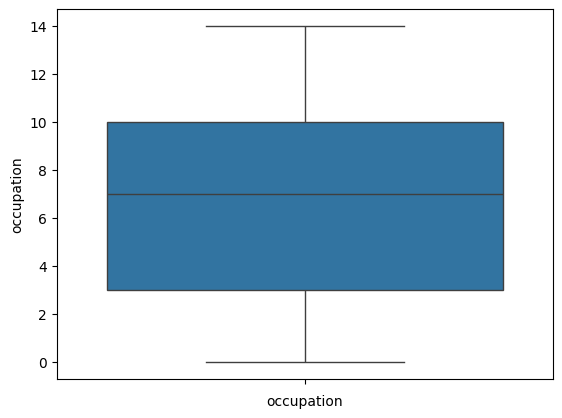

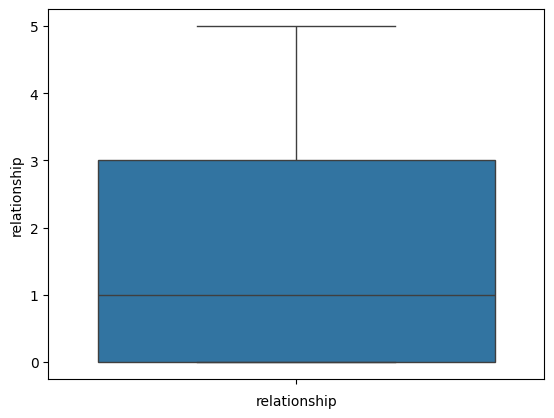

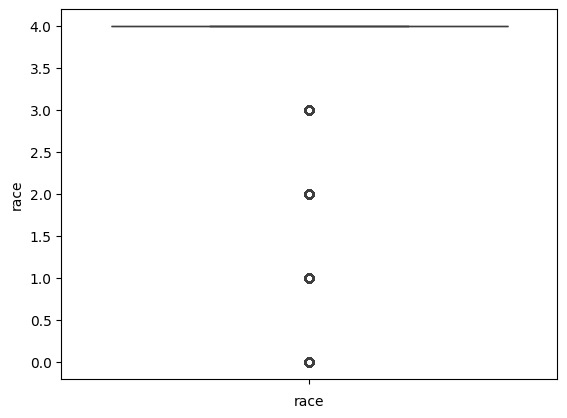

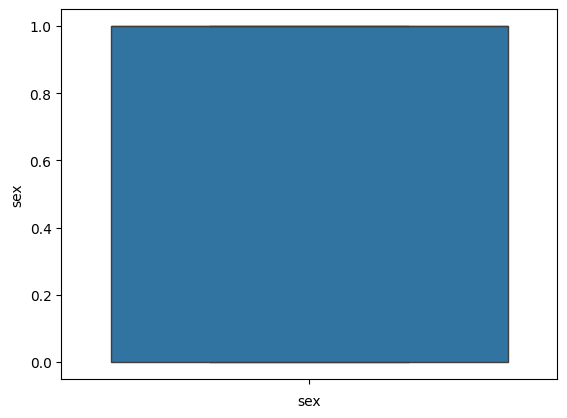

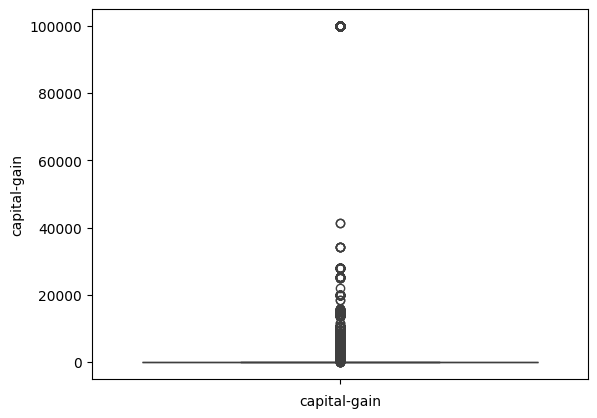

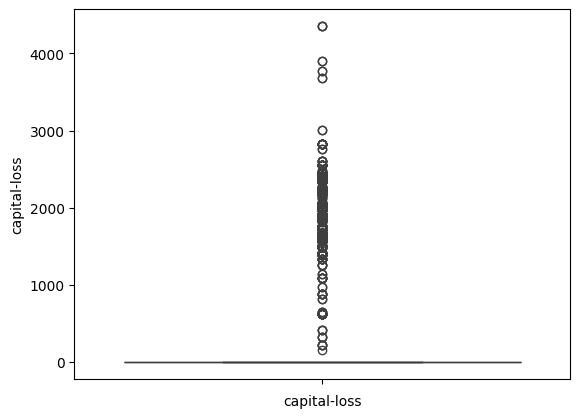

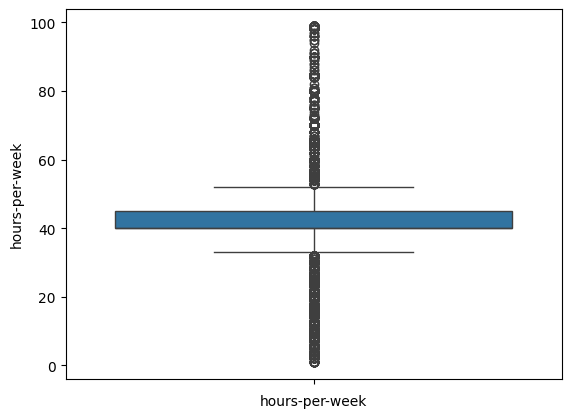

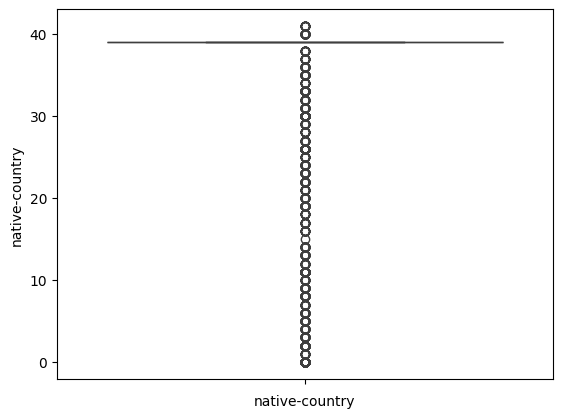

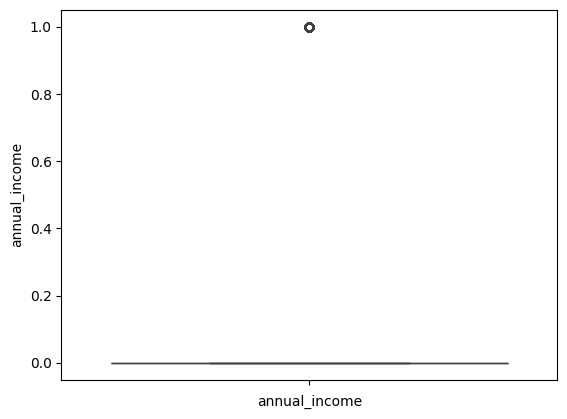

In [ ]:
#Outliers checking again after changing to numeric.
for i in df.columns:
  if df[i].dtype=='int64' or df[i].dtype=='float64':
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
#Removing outliers
cols = df.select_dtypes(include=np.number).columns
for col in cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  #outliers = df[(df[col] < lower) | (df[col] > upper)]
  #print(outliers)
  df1 = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
df1.shape

(24720, 15)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X = df1.iloc[:,:-1]
y = df1['annual_income']

In [ ]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32553,32,4,116138,12,14,4,13,1,1,1,0,0,11,36
32555,22,4,310152,15,10,4,11,1,4,1,0,0,40,39
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39


In [ ]:
y

,annual_income
0,0
1,0
2,0
3,0
4,0
...,...
32553,0
32555,0
32556,0
32558,0


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_predict = model.predict(X_test)
y_predict

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print('Decision Tree accuracy score is : ',accuracy_score(y_predict,y_test)*100)

Decision Tree accuracy score is :  100.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
classifier_obj = RandomForestClassifier(n_estimators=100)
classifier_obj.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred=classifier_obj.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print('Random forest accuracy score is : ',accuracy_score(y_pred,y_test)*100)

Random forest accuracy score is :  100.0


##If we do not remove outliers then

In [ ]:
X = df.iloc[:,:-1]
y = df['annual_income']
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0)
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_predict = model.predict(X_test)
print('Decision Tree accuracy score is : ',accuracy_score(y_predict,y_test)*100)

classifier_obj = RandomForestClassifier(n_estimators=100)
classifier_obj.fit(X_train,y_train)
y_pred=classifier_obj.predict(X_test)
print('Random forest accuracy score is : ',accuracy_score(y_pred,y_test)*100)

Decision Tree accuracy score is :  80.93044679871028
Random forest accuracy score is :  84.86104713649624
